# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/1. IT study/Data Loves Academy/Data Analyst/11. Модуль 11/data/yulu_rental.csv')

In [ ]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

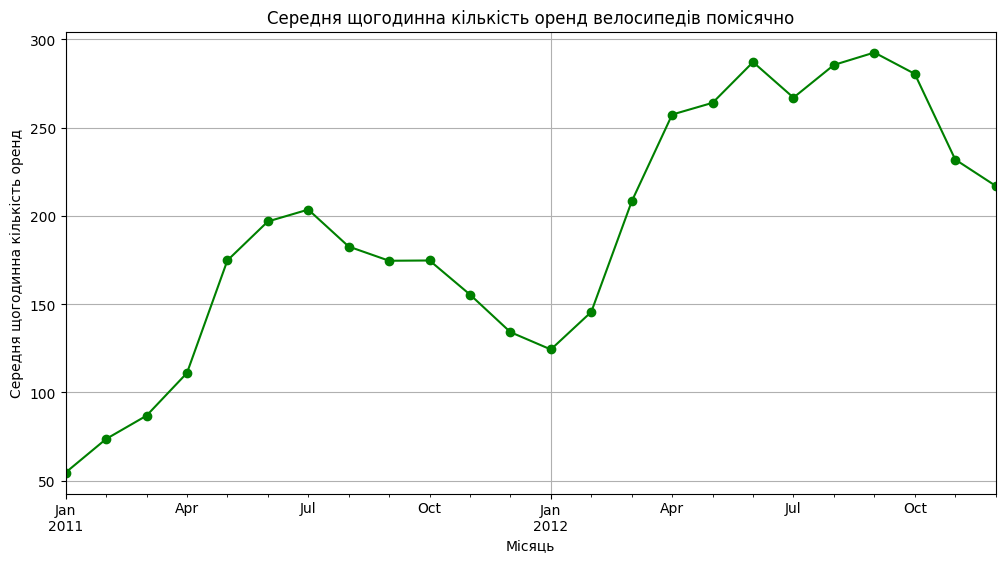

In [ ]:
# viz with Pandas

# середня кількість оренд за годину в межах кожного місяця
monthly_rentals = df['count'].resample('ME').mean()

monthly_rentals.plot(
    figsize=(12, 6),
    marker='o',
    color='green',
    title='Середня щогодинна кількість оренд велосипедів помісячно'
)

plt.xlabel('Місяць')
plt.ylabel('Середня щогодинна кількість оренд')
plt.grid(True)
plt.show()

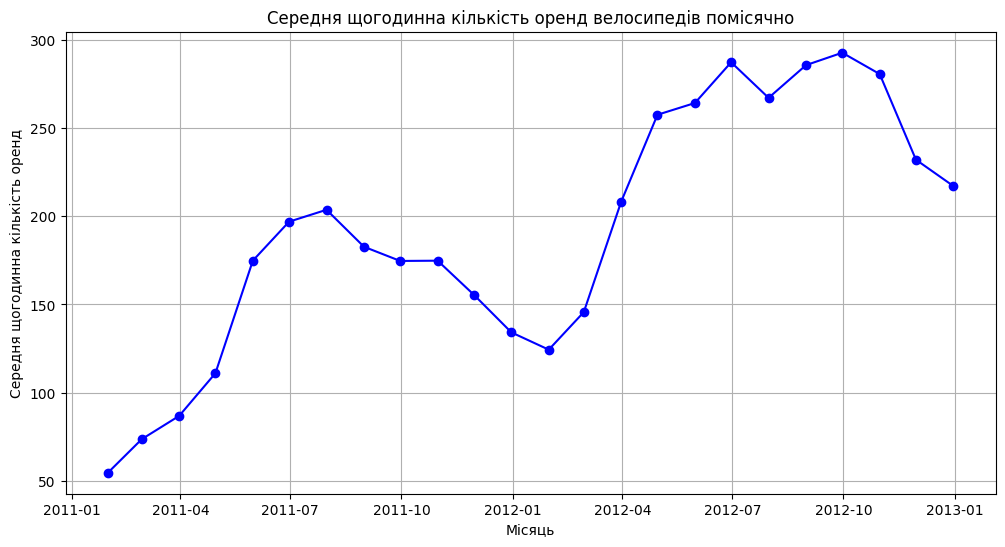

In [ ]:
# viz with Matplotlib

# середня кількість оренд за годину в межах кожного місяця
monthly_rentals = df['count'].resample('ME').mean()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_rentals.index,
    monthly_rentals.values,
    marker='o',
    color='blue'
)

plt.title('Середня щогодинна кількість оренд велосипедів помісячно')
plt.xlabel('Місяць')
plt.ylabel('Середня щогодинна кількість оренд')
plt.grid(True)

plt.show()

Сама лінія і форматування однакові в Pandas і в Matplotlib.
Відрізняються підписи осі X і діапазон по осі Х. Також сітка відрізняється (gridlines).
Більше подобається візуалізація, отримана з Matplotlib.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень продажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7]                          # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]      # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]    # Продажі за тиждень2

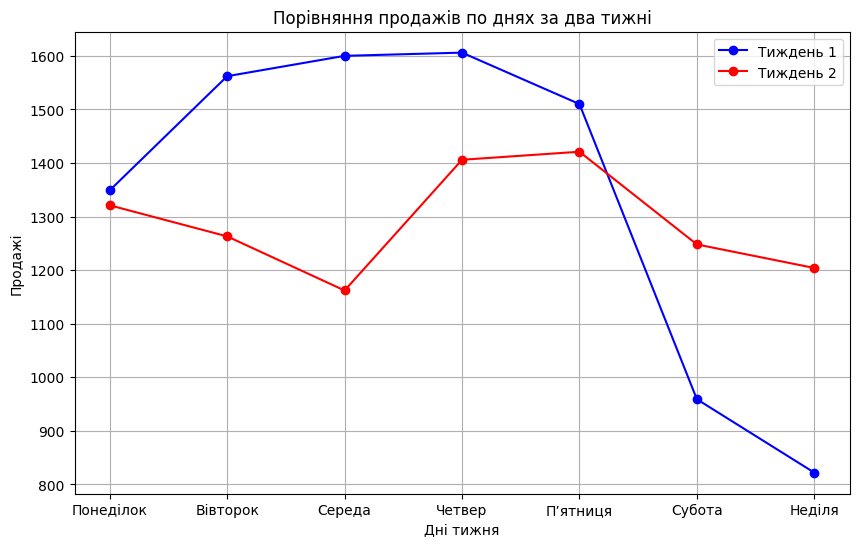

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    days,
    sales_week1,
    marker='o',
    color='blue',
    label='Тиждень 1'
)

plt.plot(
    days,
    sales_week2,
    marker='o',
    color='red',
    label='Тиждень 2'
)


plt.xticks(
    days,
    ['Понеділок', 'Вівторок', 'Середа', 'Четвер',
     'П’ятниця', 'Субота', 'Неділя']
)

plt.title('Порівняння продажів по днях за два тижні')
plt.xlabel('Дні тижня')
plt.ylabel('Продажі')

plt.legend()
plt.grid(True)

plt.show()

1. Більш стабільні продажі були у Тижні 2. Червона лінія **другого тижня виглядає більш плавною та горизонтальною**, і її значення коливаються у вужчому діапазоні - це видно і візуально. Натомість перший тиждень (синя лінія) демонструє різкі перепади: високі показники у будні дні (близько 1500–1600) стрімко падають на вихідних до 820–960.

2. Найкраще використати **стандартне відхилення `(std)`**. Воно показує, наскільки сильно значення продажів відхиляються від їхнього середнього:

- менше стандартне відхилення → продажі стабільніші
- більше стандартне відхилення → продажі сильніше коливаються

Чим менше стандартне відхилення, тим стабільніші продажі.

Як бачимо, у Тижні 2 стандартне відхилення дійсно менше, причому майже у 3 рази:

In [ ]:
print(np.std(sales_week1))
print(np.std(sales_week2))

299.99857142517004
90.9060964256355


In [ ]:
# з явним перетворенням списку на масив

sales_week1 = [1349, 1562, 1600, 1606, 1510, 959, 822]
sales_week2 = [1321, 1263, 1162, 1406, 1421, 1248, 1204]

sales_week1 = np.array(sales_week1)
sales_week2 = np.array(sales_week2)

print(np.std(sales_week1))
print(np.std(sales_week2))

299.99857142517004
90.9060964256355


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

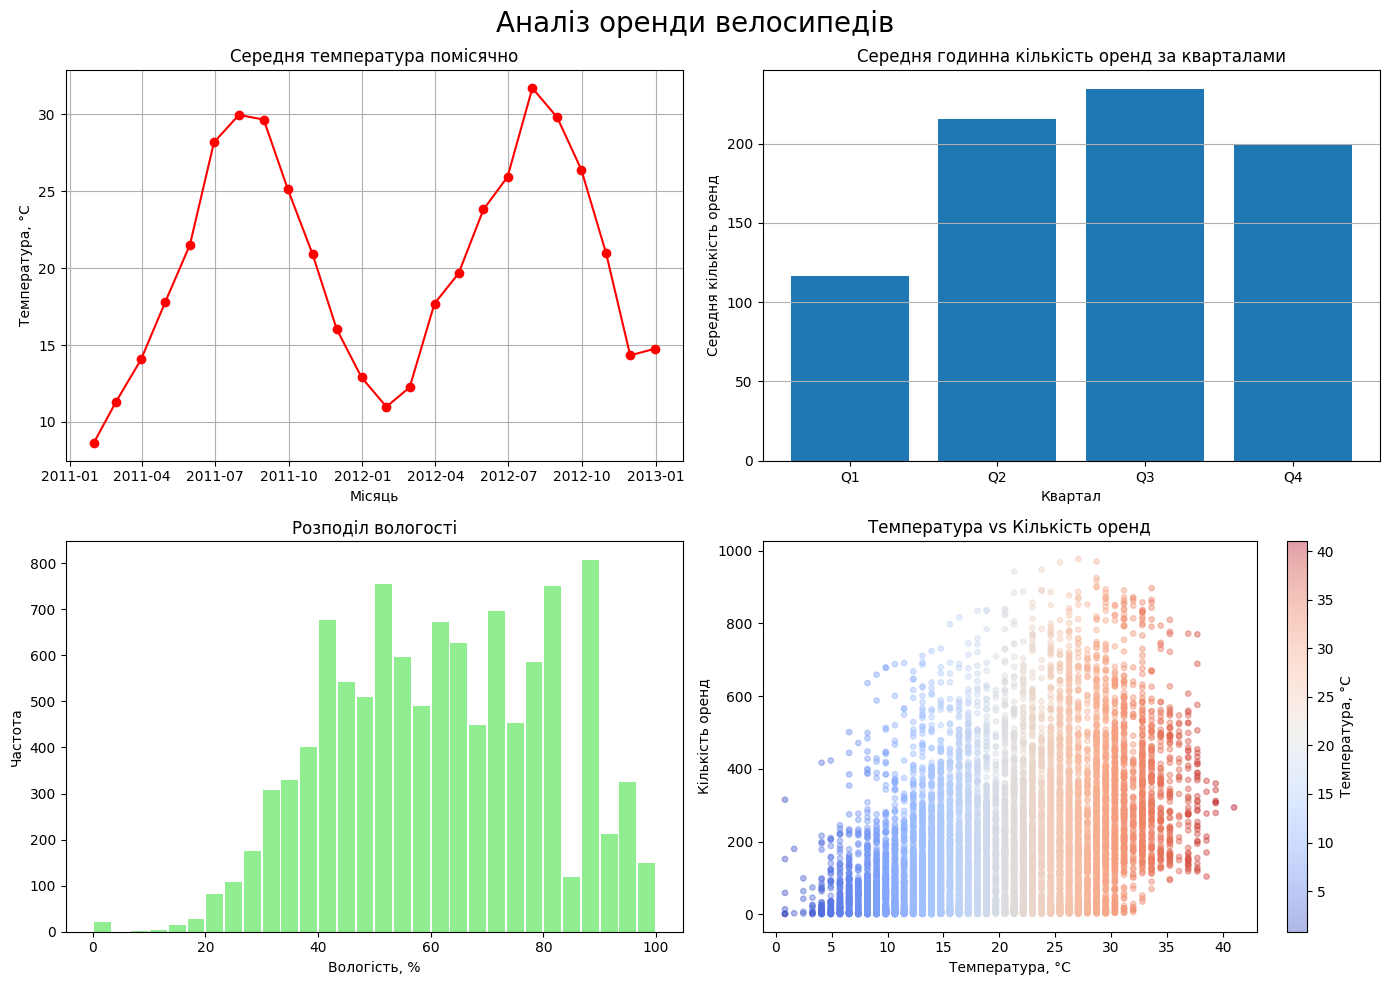

In [ ]:
import matplotlib.pyplot as plt

# 1. Середня температура помісячно
monthly_temp = df['temp'].resample('ME').mean()

# 2. Середня годинна кількість оренд за кварталами
hourly_rentals = df['count'].resample('h').mean()
quarterly_rentals = hourly_rentals.groupby(hourly_rentals.index.quarter).mean()

# 3. Вологість за всіма погодинними вимірюваннями
humidity = df['humidity']

# 4. Температура vs кількість оренд
temp = df['temp']
rentals = df['count']


# Створення сітки 2x2
plt.figure(figsize=(14, 10))

# 1. Лінійний графік
plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, 'r-o')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура, °C')
plt.grid(True)

# 2. Стовпчикова діаграма
plt.subplot(2, 2, 2)
plt.bar(['Q1', 'Q2', 'Q3', 'Q4'], quarterly_rentals)
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.grid(axis='y')

# 3. Гістограма
plt.subplot(2, 2, 3)
plt.hist(humidity, bins=30, rwidth=0.9, color='lightgreen')
plt.title('Розподіл вологості')
plt.xlabel('Вологість, %')
plt.ylabel('Частота')

# 4. Scatter plot
# plt.subplot(2, 2, 4)
# plt.scatter(temp, rentals, alpha=0.3)
# plt.title('Температура vs кількість оренд')
# plt.xlabel('Температура, °C')
# plt.ylabel('Кількість оренд')

# 4. Scatter plot
plt.subplot(2, 2, 4)
plt.scatter(temp, rentals, c=temp, cmap='coolwarm', alpha=0.4, s=15)
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура, °C')
plt.ylabel('Кількість оренд')
plt.colorbar(label='Температура, °C')

# Загальна назва
plt.suptitle('Аналіз оренди велосипедів', fontsize=20)

plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

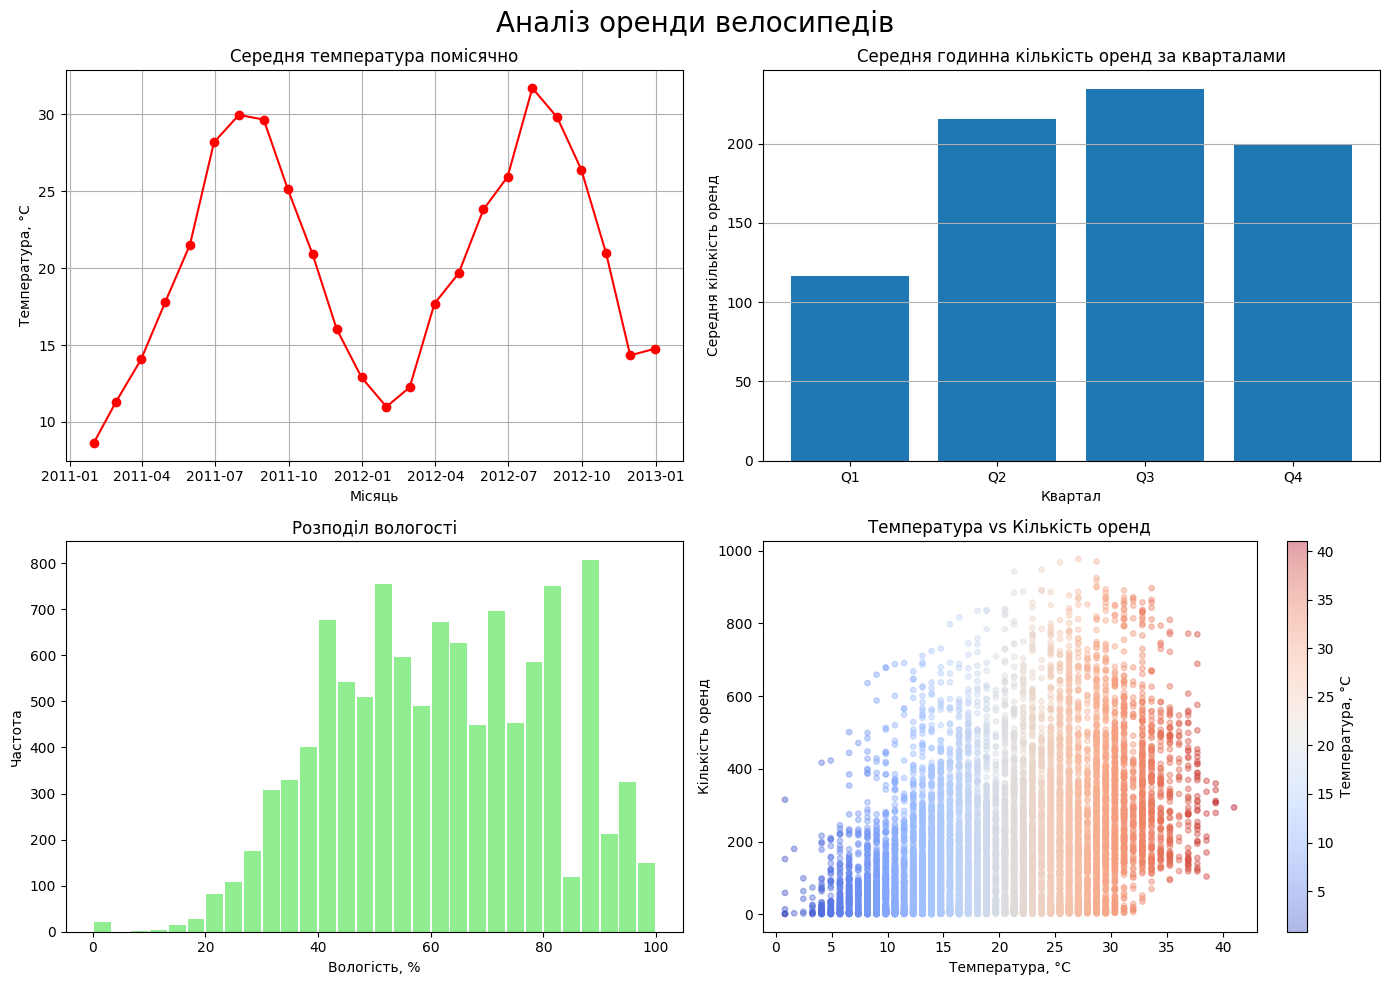

In [ ]:
import matplotlib.pyplot as plt

# 1. Середня температура помісячно
monthly_temp = df['temp'].resample('ME').mean()

# 2. Середня годинна кількість оренд за кварталами
hourly_rentals = df['count'].resample('h').mean()
quarterly_rentals = hourly_rentals.groupby(hourly_rentals.index.quarter).mean()

# 3. Вологість за всіма погодинними вимірюваннями
humidity = df['humidity']

# 4. Температура vs кількість оренд
temp = df['temp']
rentals = df['count']


# Створення сітки 2x2
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Лінійний графік
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, 'r-o')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура, °C')
ax[0, 0].grid(True)

# 2. Стовпчикова діаграма
ax[0, 1].bar(['Q1', 'Q2', 'Q3', 'Q4'], quarterly_rentals)
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')
ax[0, 1].grid(axis='y')

# 3. Гістограма
ax[1, 0].hist(humidity, bins=30, rwidth=0.9, color='lightgreen')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість, %')
ax[1, 0].set_ylabel('Частота')

# 4. Scatter plot
scatter = ax[1, 1].scatter(
    temp,
    rentals,
    c=temp,
    cmap='coolwarm',
    alpha=0.4,
    s=15
)

ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура, °C')
ax[1, 1].set_ylabel('Кількість оренд')

fig.colorbar(scatter, ax=ax[1, 1], label='Температура, °C')

# Загальна назва
fig.suptitle('Аналіз оренди велосипедів', fontsize=20)

# Автоматичне розташування
fig.tight_layout()

plt.show()

- `plt.subplot()` дозволяє створювати підграфіки по одному та перемикатися між ними, вказуючи їхню позицію в сітці. При цьому ми переважно працюємо через `plt`.

- `plt.subplots()` одразу створює всю фігуру та сітку підграфіків і повертає їх у вигляді об'єктів `fig` та `ax`. Завдяки цьому можна окремо керувати кожним графіком через відповідний елемент `ax`.

Тому `plt.subplots()` зручніший, коли потрібно створити кілька графіків і окремо налаштовувати кожен із них.

Якщо коротко: `subplot()` - створюємо/вибираємо графіки по одному, а `subplots()` - одразу створюємо всю сітку і отримуємо доступ до кожного графіка через `ax`.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

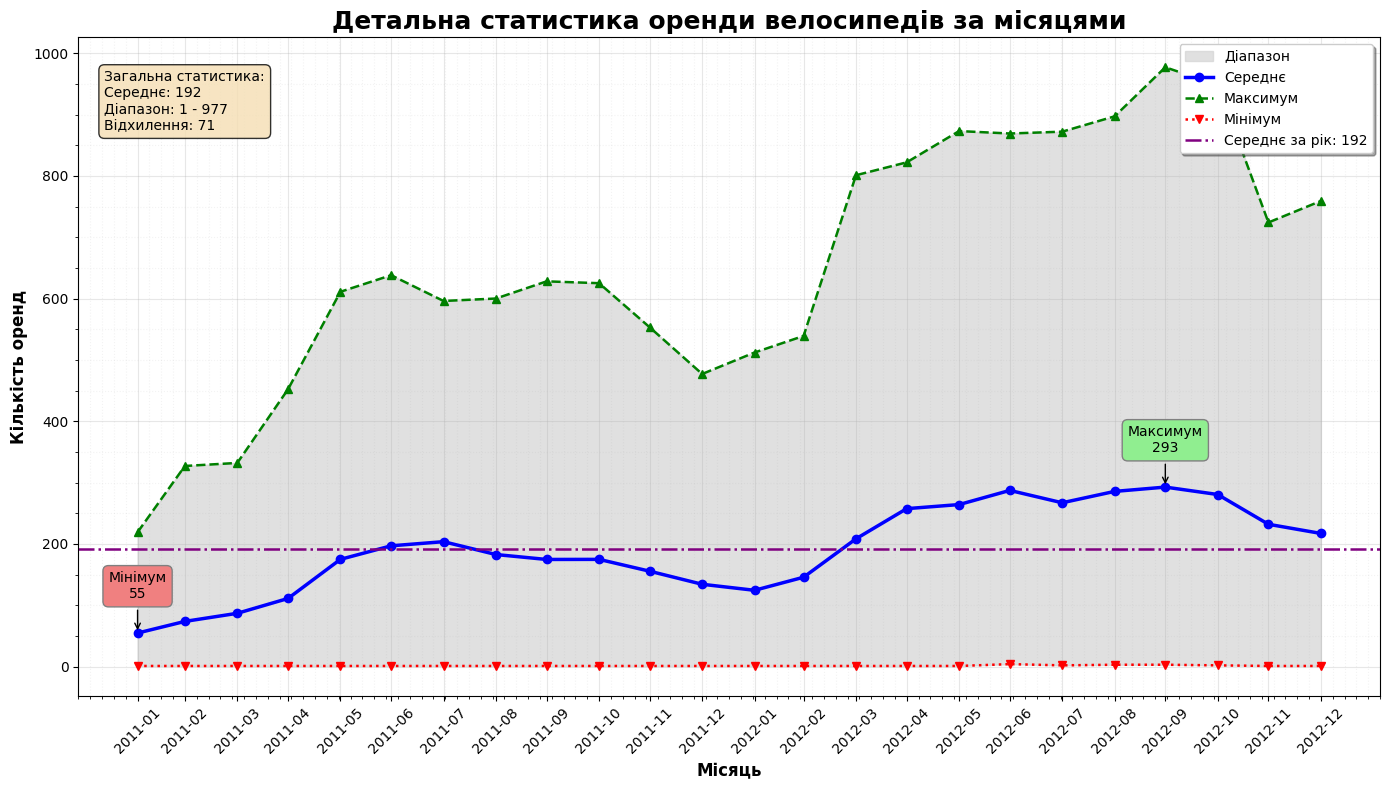

In [ ]:
import matplotlib.pyplot as plt

# Статистика оренд за місяцями
monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])

# Середнє за весь період
year_mean = df['count'].mean()

# Найвище та найнижче середнє
max_month = monthly_stats['mean'].idxmax()
max_value = monthly_stats['mean'].max()

min_month = monthly_stats['mean'].idxmin()
min_value = monthly_stats['mean'].min()


# Загальна статистика сирих даних
overall_mean = df['count'].mean()
overall_min = df['count'].min()
overall_max = df['count'].max()

# Стандартне відхилення помісячних середніх
monthly_mean_std = monthly_stats['mean'].std()


# Створення графіка
fig, ax = plt.subplots(figsize=(14, 8))


# Заливка області між мінімумом і максимумом
ax.fill_between(
    monthly_stats.index,
    monthly_stats['min'],
    monthly_stats['max'],
    color='lightgray',
    alpha=0.7,
    label='Діапазон'
)


# Середнє
ax.plot(
    monthly_stats.index,
    monthly_stats['mean'],
    color='blue',
    marker='o',
    linestyle='-',
    linewidth=2.5,
    label='Середнє'
)


# Максимум
ax.plot(
    monthly_stats.index,
    monthly_stats['max'],
    color='green',
    marker='^',
    linestyle='--',
    linewidth=1.8,
    label='Максимум'
)


# Мінімум
ax.plot(
    monthly_stats.index,
    monthly_stats['min'],
    color='red',
    marker='v',
    linestyle=':',
    linewidth=1.8,
    label='Мінімум'
)


# Середнє за весь період
ax.axhline(
    year_mean,
    color='purple',
    linestyle='-.',
    linewidth=1.8,
    label=f'Середнє за рік: {year_mean:.0f}'
)


# Анотація максимуму
ax.annotate(
    f'Максимум\n{max_value:.0f}',
    xy=(max_month, max_value),
    xytext=(0, 25),
    textcoords='offset points',
    ha='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='lightgreen',
        edgecolor='gray'
    ),
    arrowprops=dict(arrowstyle='->')
)


# Анотація мінімуму
ax.annotate(
    f'Мінімум\n{min_value:.0f}',
    xy=(min_month, min_value),
    xytext=(0, 25),
    textcoords='offset points',
    ha='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='lightcoral',
        edgecolor='gray'
    ),
    arrowprops=dict(arrowstyle='->')
)


# Основна сітка
ax.grid(
    which='major',
    linestyle='-',
    alpha=0.3
)

# Допоміжна сітка
ax.minorticks_on()

ax.grid(
    which='minor',
    linestyle=':',
    alpha=0.15
)


# Заголовок
ax.set_title(
    'Детальна статистика оренди велосипедів за місяцями',
    fontsize=18,
    fontweight='bold'
)


# Підписи осей
ax.set_xlabel(
    'Місяць',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Кількість оренд',
    fontsize=12,
    fontweight='bold'
)


# Формат підписів місяців
ax.set_xticks(monthly_stats.index)
ax.set_xticklabels(
    monthly_stats.index.strftime('%Y-%m'),
    rotation=45
)


# Легенда
ax.legend(
    loc='upper right',
    shadow=True,
    frameon=True
)


# Текстовий блок зі статистикою
#stats_text = (
#    f'Загальна статистика:\n'
#    f'Середнє: {year_mean:.0f}\n'
#    f'Діапазон: {min_value:.0f} – {max_value:.0f}\n'
#    f'Відхилення: {max_value - min_value:.0f}'
#)



stats_text = (
    f'Загальна статистика:\n'
    f'Середнє: {overall_mean:.0f}\n'
    f'Діапазон: {overall_min:.0f} - {overall_max:.0f}\n'
    f'Відхилення: {monthly_mean_std:.0f}'
)



ax.text(
    0.02,
    0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='wheat',
        alpha=0.8
    )
)


plt.tight_layout()
plt.show()

**Питання для інтерпретації:**

1. **Перевага додавання анотацій:** Анотації дозволяють швидко привернути увагу глядача до ключових точок (максимумів, мінімумів або аномалій) і чітко їх позначити, таким чином, позбавляють глядача необхідності самостійно шукати ці значення за осями координат.

2. **Призначення `fill_between()`:** Цей метод використовується для заповнення кольором простору між двома лініями (на графіку - між верхньою межею максимуму та основою). Він візуально підкреслює загальний діапазон розкиду даних, таким чином, допомагає оцінити варіативність показників та загальний обсяг розподілу.

3. **Роль текстового блоку:** Текстовий блок (у нас - плашка з підсумковою статистикою у верхньому лівому кутку) надає зведену інформацію про весь набір даних (середнє значення, діапазон, стандартне відхилення) в одному місці, таким чином, дозволяє швидко зрозуміти загальну картину без додаткових розрахунків чи звернень до таблиць.